In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd

# Step 1: Load the Walmart dataset
df = pd.read_csv("/kaggle/input/datasets/yasserh/walmart-dataset/Walmart.csv")

# Step 2: Display the first 5 rows
print("First 5 rows:")
print(df.head())

# Step 3: Display column names
print("\nColumn Names:")
print(df.columns)

# Step 4: Check dataset information
print("\nDataset Information:")
print(df.info())

# Step 5: Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Step 6: Check for duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# Step 7: Remove completely blank rows
df = df.dropna(how="all")

# Step 8: Remove duplicate rows
df = df.drop_duplicates()

# Step 9: Convert Date column to Date format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Step 10: Convert Store to integer
df["Store"] = pd.to_numeric(df["Store"], errors="coerce")

# Step 11: Convert numeric columns to numeric data types
numeric_columns = [
    "Weekly_Sales",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Step 12: Check missing values after conversion
print("\nMissing Values After Conversion:")
print(df.isnull().sum())

# Step 13: Remove rows where Weekly_Sales is missing
df = df.dropna(subset=["Weekly_Sales"])

# Step 14: Remove negative Weekly_Sales values
df = df[df["Weekly_Sales"] >= 0]

# Step 15: Check Holiday_Flag values
print("\nHoliday Flag Values:")
print(df["Holiday_Flag"].unique())

# Step 16: Keep only valid Holiday_Flag values (0 and 1)
df = df[df["Holiday_Flag"].isin([0, 1])]

# Step 17: Display final dataset
print("\nCleaned Dataset:")
print(df.head())

# Step 18: Display final dataset information
print("\nFinal Dataset Information:")
print(df.info())

# Step 19: Check remaining duplicates
print("\nRemaining Duplicate Rows:")
print(df.duplicated().sum())

# Step 20: Check final shape
print("\nFinal Dataset Shape:")
print(df.shape)

First 5 rows:
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  

Column Names:
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        

First 5 rows:
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  

Column Names:
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

Dataset Shape:
(6435, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  D

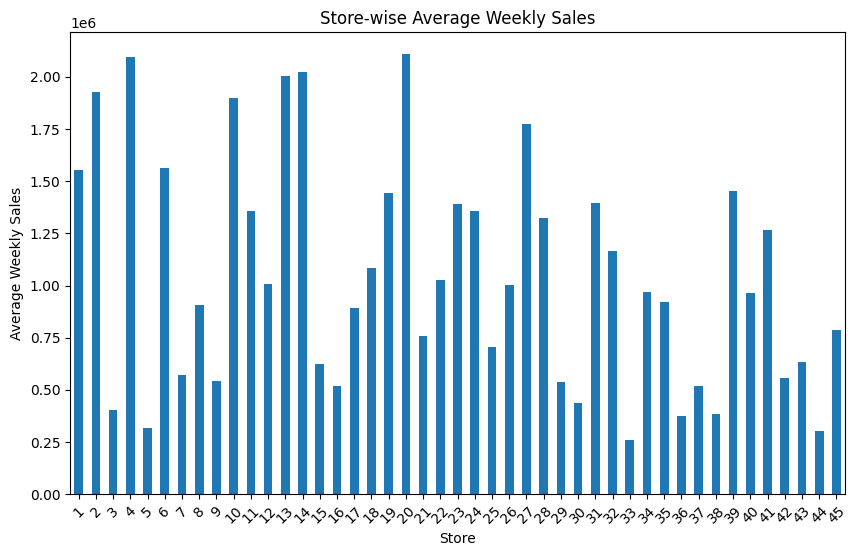

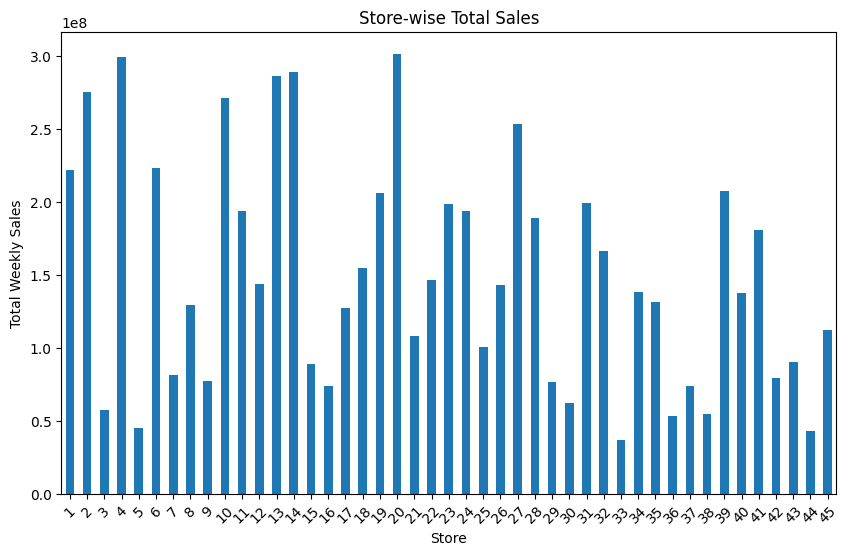

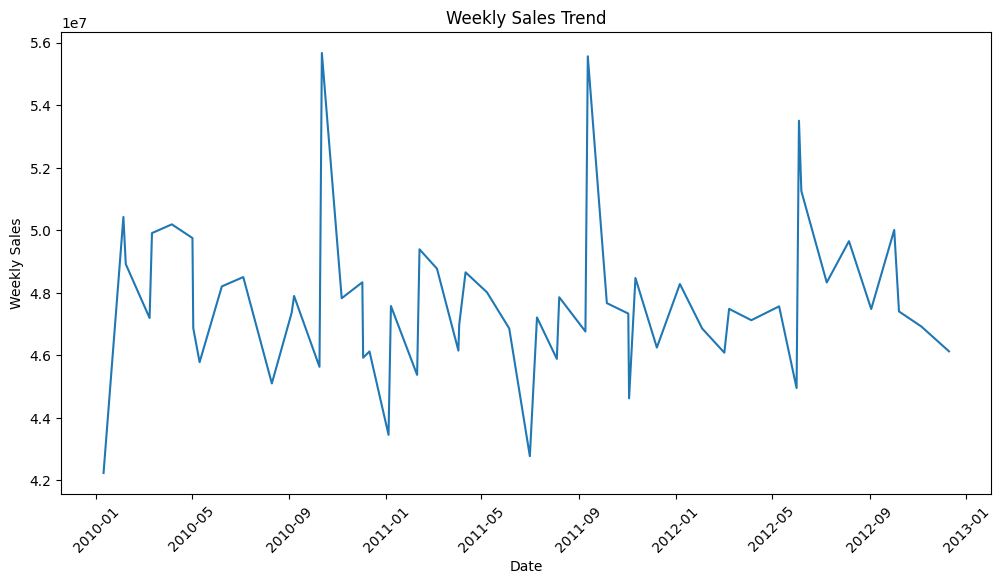

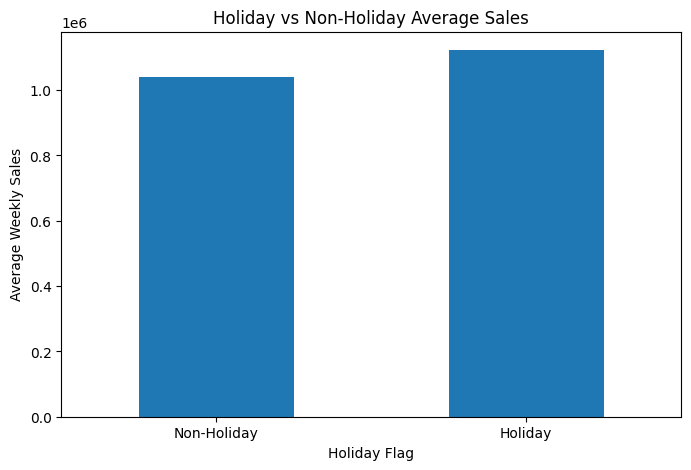

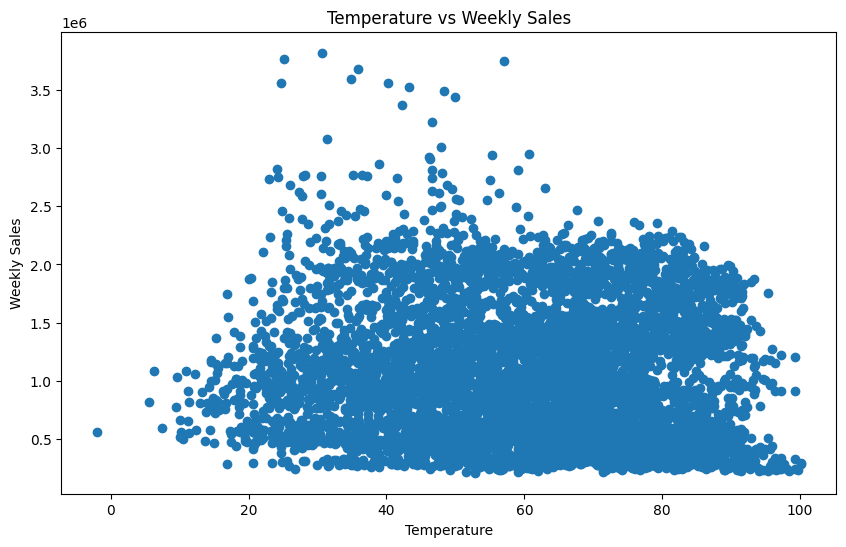

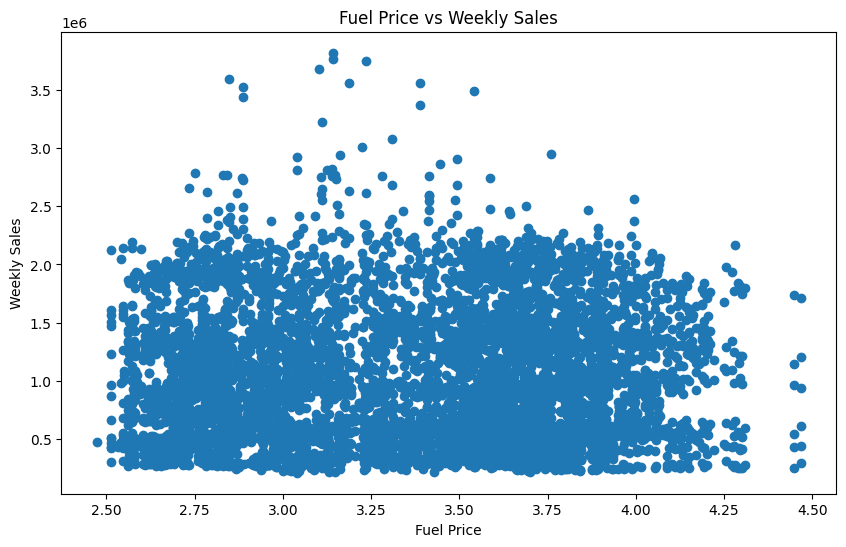

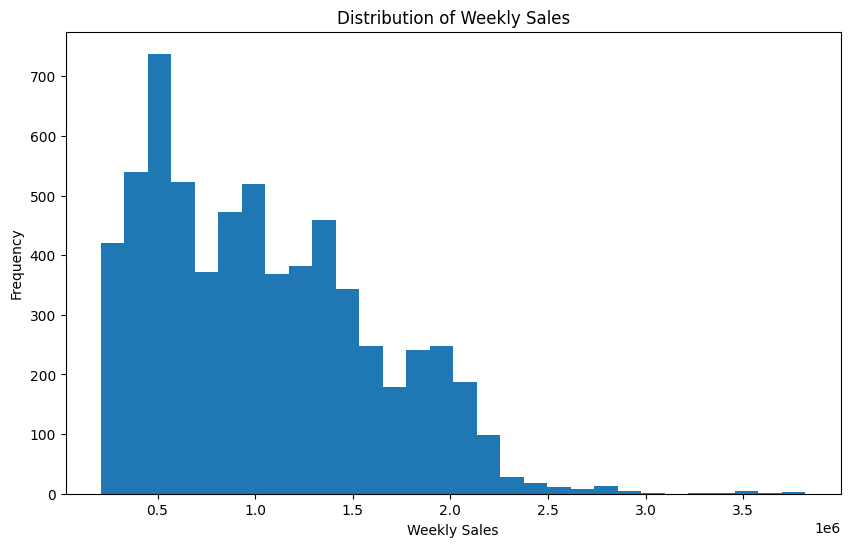

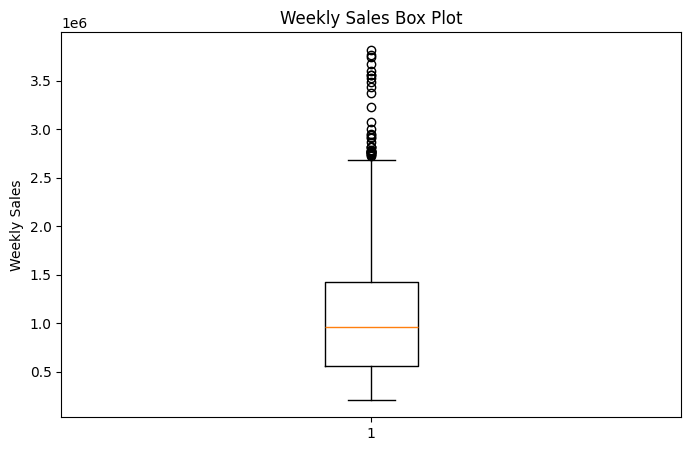

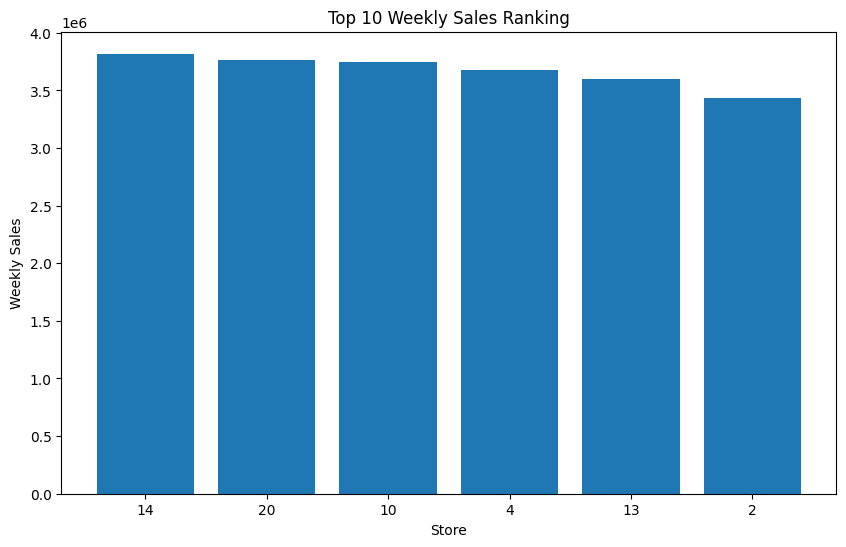


Final Dataset:
   Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1 2010-05-02    1643690.90             0        42.31       2.572   
1      1 2010-12-02    1641957.44             1        38.51       2.548   
2      1        NaT    1611968.17             0        39.93       2.514   
3      1        NaT    1409727.59             0        46.63       2.561   
4      1 2010-05-03    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  

Final Dataset Shape:
(6435, 8)

Final Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          2565 non-nul

In [3]:
# ============================================
# WALMART DATASET - COMPLETE PROGRAM
# Data Cleaning, Analysis and Visualization
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. LOAD DATASET
# --------------------------------------------

df = pd.read_csv("/kaggle/input/datasets/yasserh/walmart-dataset/Walmart.csv")

print("First 5 rows:")
print(df.head())


# --------------------------------------------
# 2. BASIC DATA UNDERSTANDING
# --------------------------------------------

print("\nColumn Names:")
print(df.columns)

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())


# --------------------------------------------
# 3. CHECK MISSING VALUES
# --------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


# --------------------------------------------
# 4. CHECK DUPLICATE ROWS
# --------------------------------------------

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())


# --------------------------------------------
# 5. REMOVE BLANK ROWS
# --------------------------------------------

df = df.dropna(how="all")


# --------------------------------------------
# 6. REMOVE DUPLICATE ROWS
# --------------------------------------------

df = df.drop_duplicates()


# --------------------------------------------
# 7. CONVERT DATE COLUMN
# --------------------------------------------

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)


# --------------------------------------------
# 8. CONVERT NUMERIC COLUMNS
# --------------------------------------------

numeric_columns = [
    "Store",
    "Weekly_Sales",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


# --------------------------------------------
# 9. CHECK MISSING VALUES AGAIN
# --------------------------------------------

print("\nMissing Values After Conversion:")
print(df.isnull().sum())


# --------------------------------------------
# 10. REMOVE ROWS WITH MISSING WEEKLY SALES
# --------------------------------------------

df = df.dropna(
    subset=["Weekly_Sales"]
)


# --------------------------------------------
# 11. REMOVE NEGATIVE SALES
# --------------------------------------------

df = df[
    df["Weekly_Sales"] >= 0
]


# --------------------------------------------
# 12. CHECK HOLIDAY FLAG
# --------------------------------------------

print("\nHoliday Flag Values:")
print(df["Holiday_Flag"].unique())


# Keep only 0 and 1
df = df[
    df["Holiday_Flag"].isin([0, 1])
]


# ============================================
# STATISTICAL ANALYSIS
# ============================================

# --------------------------------------------
# 13. MEAN
# --------------------------------------------

print("\nMean Weekly Sales:")
print(df["Weekly_Sales"].mean())


# --------------------------------------------
# 14. MEDIAN
# --------------------------------------------

print("\nMedian Weekly Sales:")
print(df["Weekly_Sales"].median())


# --------------------------------------------
# 15. MODE
# --------------------------------------------

print("\nMode Weekly Sales:")
print(df["Weekly_Sales"].mode())


# --------------------------------------------
# 16. STANDARD DEVIATION
# --------------------------------------------

print("\nStandard Deviation:")
print(df["Weekly_Sales"].std())


# --------------------------------------------
# 17. VARIANCE
# --------------------------------------------

print("\nVariance:")
print(df["Weekly_Sales"].var())


# --------------------------------------------
# 18. IQR
# --------------------------------------------

Q1 = df["Weekly_Sales"].quantile(0.25)
Q3 = df["Weekly_Sales"].quantile(0.75)

IQR = Q3 - Q1

print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


# --------------------------------------------
# 19. CORRELATION
# --------------------------------------------

corr = df[
    [
        "Weekly_Sales",
        "Temperature"
    ]
].corr()

print("\nCorrelation:")
print(corr)


# ============================================
# VISUALIZATIONS
# ============================================

# --------------------------------------------
# GRAPH 1: STORE-WISE AVERAGE WEEKLY SALES
# --------------------------------------------

avg_sales = df.groupby(
    "Store"
)["Weekly_Sales"].mean()

plt.figure(figsize=(10, 6))

avg_sales.plot(
    kind="bar"
)

plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.title("Store-wise Average Weekly Sales")
plt.xticks(rotation=45)

plt.show()


# --------------------------------------------
# GRAPH 2: STORE-WISE TOTAL SALES
# --------------------------------------------

total_sales = df.groupby(
    "Store"
)["Weekly_Sales"].sum()

plt.figure(figsize=(10, 6))

total_sales.plot(
    kind="bar"
)

plt.xlabel("Store")
plt.ylabel("Total Weekly Sales")
plt.title("Store-wise Total Sales")
plt.xticks(rotation=45)

plt.show()


# --------------------------------------------
# GRAPH 3: WEEKLY SALES TREND
# --------------------------------------------

date_sales = df.groupby(
    "Date"
)["Weekly_Sales"].sum()

plt.figure(figsize=(12, 6))

plt.plot(
    date_sales.index,
    date_sales.values
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.title("Weekly Sales Trend")

plt.xticks(rotation=45)

plt.show()


# --------------------------------------------
# GRAPH 4: HOLIDAY VS NON-HOLIDAY SALES
# --------------------------------------------

holiday_sales = df.groupby(
    "Holiday_Flag"
)["Weekly_Sales"].mean()

plt.figure(figsize=(8, 5))

holiday_sales.plot(
    kind="bar"
)

plt.xlabel("Holiday Flag")
plt.ylabel("Average Weekly Sales")
plt.title("Holiday vs Non-Holiday Average Sales")

plt.xticks(
    [0, 1],
    ["Non-Holiday", "Holiday"],
    rotation=0
)

plt.show()


# --------------------------------------------
# GRAPH 5: TEMPERATURE VS WEEKLY SALES
# --------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Temperature"],
    df["Weekly_Sales"]
)

plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.title("Temperature vs Weekly Sales")

plt.show()


# --------------------------------------------
# GRAPH 6: FUEL PRICE VS WEEKLY SALES
# --------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Fuel_Price"],
    df["Weekly_Sales"]
)

plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")
plt.title("Fuel Price vs Weekly Sales")

plt.show()


# --------------------------------------------
# GRAPH 7: WEEKLY SALES DISTRIBUTION
# --------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    df["Weekly_Sales"],
    bins=30
)

plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Weekly Sales")

plt.show()


# --------------------------------------------
# GRAPH 8: WEEKLY SALES BOX PLOT
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.boxplot(
    df["Weekly_Sales"]
)

plt.ylabel("Weekly Sales")
plt.title("Weekly Sales Box Plot")

plt.show()


# --------------------------------------------
# GRAPH 9: SALES RANKING
# --------------------------------------------

top_10 = df.sort_values(
    by="Weekly_Sales",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10["Store"].astype(str),
    top_10["Weekly_Sales"]
)

plt.xlabel("Store")
plt.ylabel("Weekly Sales")
plt.title("Top 10 Weekly Sales Ranking")

plt.show()


# ============================================
# FINAL DATASET
# ============================================

print("\nFinal Dataset:")
print(df.head())

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Dataset Information:")
df.info()